In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import constants, units
from astropy.coordinates import Angle
from scipy.optimize import curve_fit
import pandas as pd
import os
from scipy.signal import medfilt

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/MUSE/'

Load in the segmentation map for galaxy IDs

In [3]:
cat_file = np.loadtxt(rootdir + 'test_new_updated.cat')

In [4]:
gal_ids_arr = np.int_(cat_file[:,0])
z_ids_arr = cat_file[:,12]

In [5]:
gal_id = 1

In [6]:
idx = np.where(gal_ids_arr==gal_id)[0][0]

In [7]:
z_best = z_ids_arr[idx]

In [8]:
gal_spec_arr = np.loadtxt(rootdir+'gal{}/gal{}_spec.dat'.format(gal_id, gal_id), delimiter='\t')

In [9]:
wav_arr = gal_spec_arr[:,0]
gal_spec_raw = gal_spec_arr[:,1]
gal_spec_err = gal_spec_arr[:,2]
gal_spec_fit = gal_spec_arr[:,3]

In [10]:
B_center = 4450
B_fwhm = 940
B_sigma = B_fwhm/(2*np.sqrt(2*np.log(2)))

V_center = 5510
V_fwhm = 880
V_sigma = V_fwhm/(2*np.sqrt(2*np.log(2)))

In [11]:
n_span = 1

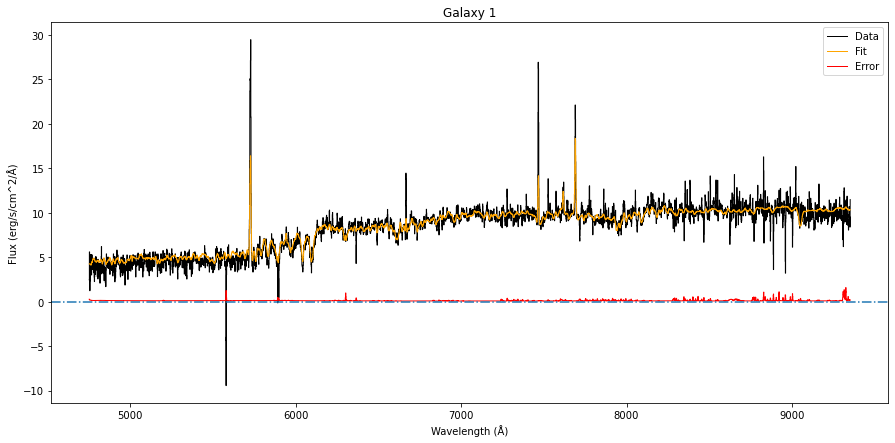

In [13]:
fig, ax = plt.subplots(1, figsize=(15,7))

ax.step(wav_arr, gal_spec_raw, label='Data', color='black', lw=1, where='mid')
ax.step(wav_arr, gal_spec_fit, label='Fit', color='orange', lw=1, where='mid')
ax.step(wav_arr, gal_spec_err, label='Error', color='red', lw=1, where='mid')

ax.axhline(0, linestyle='-.')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (erg/s/cm^2/Å)')
ax.set_title('Galaxy {}'.format(gal_id))

ax.legend()